✅ TensorFlow version: 2.18.0
✅ GPU available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.4592 - loss: 1.4538 - val_accuracy: 0.7734 - val_loss: 0.6266 - learning_rate: 1.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 686ms/step - accuracy: 0.8771 - loss: 0.3731 - val_accuracy: 0.8012 - val_loss: 0.6219 - learning_rate: 1.0000e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 676ms/step - accuracy: 0.9040 - loss: 0.2417 - val_accuracy: 0.8310 - val_loss: 0.5312 - learning_rate: 1.0000e-04
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 670ms/step - accuracy: 0.9538 - loss: 0.1272 - val_accuracy: 0.8410 - val_loss: 0.5248 - learning_rate: 1.0000e-04
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s 709ms/step - accuracy: 0.9577 - loss: 0.1296 - val_accuracy: 0.8370 - val_loss: 0.6441 - learning_rate: 1.0000e-04
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 696ms/step - accuracy: 0.9775 - loss: 0.0701 - val_accuracy: 0.8787 - val_loss: 0.4351 - learning_rate: 1.0000e-04
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 666ms/step - accur

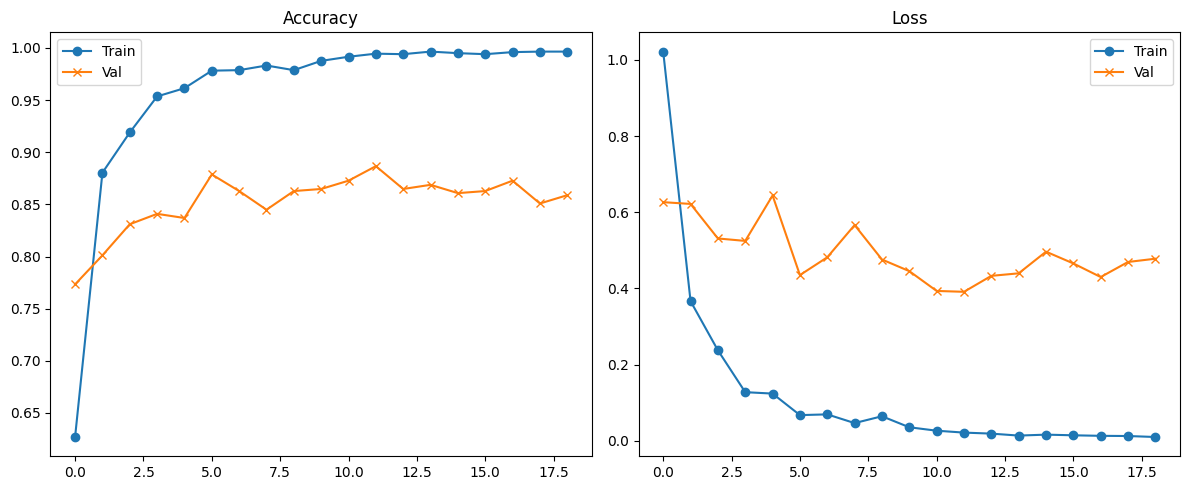

✅ Classes used in training:
0: cardboard
1: glass
2: metal
3: paper
4: plastic
5: trash


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=/content/drive/MyDrive/project/resnet50_tf_garbage_classifier.kears.

In [ ]:


import os, zipfile, matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.utils import class_weight
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# === GPU SETUP ===
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU available:", gpus[0])
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
else:
    print("No GPU detected. Enable GPU via Runtime > Change runtime type.")

# === UNZIP ALL CLASS FOLDERS ===
zip_files = {
    "cardboard": "/content/drive/MyDrive/project/cardboard.zip",
    "glass": "/content/drive/MyDrive/project/glass.zip",
    "metal": "/content/drive/MyDrive/project/metal.zip",
    "paper": "/content/drive/MyDrive/project/paper.zip",
    "plastic": "/content/drive/MyDrive/project/plastic.zip",
    "trash": "/content/drive/MyDrive/project/trash.zip"
}
dataset_dir = "/content/drive/MyDrive/project/DATASET"
os.makedirs(dataset_dir, exist_ok=True)
for class_name, zip_path in zip_files.items():
    class_dir = os.path.join(dataset_dir, class_name)
    os.makedirs(class_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(class_dir)

# === IMAGE GENERATORS ===
img_size = 224
batch_size = 32
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
train_gen = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === COMPUTE CLASS WEIGHTS ===
labels = train_gen.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))

# === BUILD RESNET50 MODEL ===
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3))
for layer in base_model.layers[:-60]:
    layer.trainable = False
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax', dtype='float32')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# === TRAIN MODEL ===
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stop]
)

# === PLOT ACCURACY & LOSS ===
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train", marker='o')
plt.plot(history.history['val_accuracy'], label="Val", marker='x')
plt.title("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train", marker='o')
plt.plot(history.history['val_loss'], label="Val", marker='x')
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# === PRINT CLASS INDICES ===
print("Classes used in training:")
for class_name, index in train_gen.class_indices.items():
    print(f"{index}: {class_name}")

# === SAVE MODEL ===



In [ ]:
model.save("/content/drive/MyDrive/project/resnet50_tf_garbage_classifier.keras")
print("✅ Model saved as resnet50_tf_garbage_classifier.h5")

✅ Model saved as resnet50_tf_garbage_classifier.h5


In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

# This command downloads and caches the dataset
dataset = load_dataset("amazon_polarity")

# Check dataset info
print(dataset)

# Look at the first sample
print(dataset['train'][0])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00004.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

train-00001-of-00004.parquet:   0%|          | 0.00/258M [00:00<?, ?B/s]

train-00002-of-00004.parquet:   0%|          | 0.00/255M [00:00<?, ?B/s]

train-00003-of-00004.parquet:   0%|          | 0.00/254M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})
{'label': 1, 'title': 'Stuning even for the non-gamer', 'content': 'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'}
